# 4단계 — BERT 파인튜닝 (KR-ELECTRA)

한국어 사전학습 모델 `snunlp/KR-ELECTRA-discriminator`를 스팸 분류에 맞게 파인튜닝합니다.

구조:
```
[CLS] 제목 [SEP] 본문 [SEP]
        ↓
   BERT Encoder
        ↓
  [CLS] 벡터 (768)
        ↓
  Dropout(0.3)
        ↓
  Linear(768→2) → Softmax → [ham 확률, spam 확률]
```

> **주의:** GPU가 있으면 훨씬 빠릅니다. CPU만 있는 경우 에폭당 수십 분 소요될 수 있습니다.

In [18]:
import sys
sys.path.insert(0, "..")

import torch
print(f"PyTorch 버전: {torch.__version__}")
print(f"CUDA 사용 가능: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch 버전: 2.11.0+cpu
CUDA 사용 가능: False


## 데이터 로드 & 전처리

In [ ]:
from src.data.preprocessor import Preprocessor
from src.data.loader import load_datasets

pre = Preprocessor(use_konlpy=False)

DATA_PATHS = [
    "../data/translated_en_to_ko.csv",
       # 3,000개 템플릿 생성
]

data = load_datasets(
    csv_paths=DATA_PATHS,
    preprocessor=pre,
    train_ratio=0.8,
    val_ratio=0.1,
    random_state=42,
)

FileNotFoundError: [Errno 2] No such file or directory: '../data/claude_generated_ko.csv'

## 토크나이저 확인

In [ ]:
from transformers import AutoTokenizer

MODEL_NAME = 'snunlp/KR-ELECTRA-discriminator'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

sample = '무료 대출 1억 지금 바로 신청하세요'
tokens = tokenizer(sample, return_tensors='pt', max_length=64, truncation=True)
print('토큰 ID:', tokens['input_ids'][0].tolist())
print('디코딩:', tokenizer.convert_ids_to_tokens(tokens['input_ids'][0]))

c:\Users\ion01\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


토큰 ID: [2, 10350, 9294, 21, 5409, 8374, 8498, 9174, 5105, 9157, 3]
디코딩: ['[CLS]', '무료', '대출', '1', '##억', '지금', '바로', '신청', '##하', '##세요', '[SEP]']


## 모델 학습

> CPU 환경에서 빠른 테스트를 위해 `epochs=1`, 데이터 일부만 사용합니다.
> 실제 학습 시에는 `python -m src.train --model bert`를 사용하세요.

In [ ]:
from src.models.bert_model import BERTSpamClassifier

# CPU 빠른 테스트: 데이터 200개, 1에폭
QUICK_TEST = not torch.cuda.is_available()

if QUICK_TEST:
    print('[안내] CPU 환경 감지 — 소규모 데이터(200개)로 1에폭 테스트 실행')
    X_tr, y_tr = data.X_train[:200], data.y_train[:200]
    X_v,  y_v  = data.X_val[:50],   data.y_val[:50]
    epochs = 1
    batch_size = 8
else:
    print('[안내] GPU 감지 — 전체 데이터로 학습')
    X_tr, y_tr = data.X_train, data.y_train
    X_v,  y_v  = data.X_val,   data.y_val
    epochs = 5
    batch_size = 32

bert = BERTSpamClassifier(
    base_model=MODEL_NAME,
    max_length=128,
    batch_size=batch_size,
    epochs=epochs,
    learning_rate=2e-5,
    spam_threshold=0.7,
    early_stopping_patience=3,   # val_f1 개선 없으면 3에폭 후 조기 종료
)

bert.fit(X_tr, y_tr, X_v, y_v)

[안내] CPU 환경 감지 — 소규모 데이터(200개)로 1에폭 테스트 실행
[BERT] 디바이스: cpu


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 61579.81it/s]
ElectraForSequenceClassification LOAD REPORT from: snunlp/KR-ELECTRA-discriminator
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
electra.embeddings.position_ids                   | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.weight                           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[BERT] Epoch 1/1 | train_loss=0.6657 | val_f1=0.0000


## Test 세트 평가

In [ ]:
import time
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

X_test_eval = data.X_test[:100] if QUICK_TEST else data.X_test
y_test_eval = data.y_test[:100] if QUICK_TEST else data.y_test

t0 = time.perf_counter()
results = bert.predict(X_test_eval)
elapsed_ms = (time.perf_counter() - t0) * 1000

y_pred = [1 if r.label == 'spam' else 0 for r in results]

print(classification_report(y_test_eval, y_pred, target_names=['ham', 'spam']))
print(f'추론 시간: {elapsed_ms:.1f}ms | 평균 {elapsed_ms/len(X_test_eval):.1f}ms/건')

              precision    recall  f1-score   support

         ham       0.47      1.00      0.64        47
        spam       0.00      0.00      0.00        53

    accuracy                           0.47       100
   macro avg       0.23      0.50      0.32       100
weighted avg       0.22      0.47      0.30       100

추론 시간: 4193.4ms | 평균 41.9ms/건


c:\Users\ion01\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ion01\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ion01\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

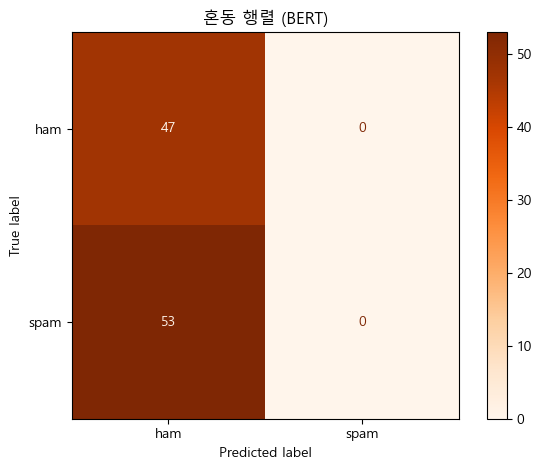

In [ ]:
cm = confusion_matrix(y_test_eval, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['ham', 'spam'])
disp.plot(cmap='Oranges')
plt.title('혼동 행렬 (BERT)')
plt.tight_layout()
plt.show()

## 학습 곡선 (오버피팅 진단)

Train Loss와 Val F1 추이로 오버피팅 여부를 확인합니다.
- Train Loss는 계속 내려가는데 Val F1이 멈추거나 하락하면 오버피팅
-  복원(early stopping)이 적용되어 최적 체크포인트를 자동 선택합니다

최적 Val F1: 0.0000 (Epoch 1)
✅  학습 안정적


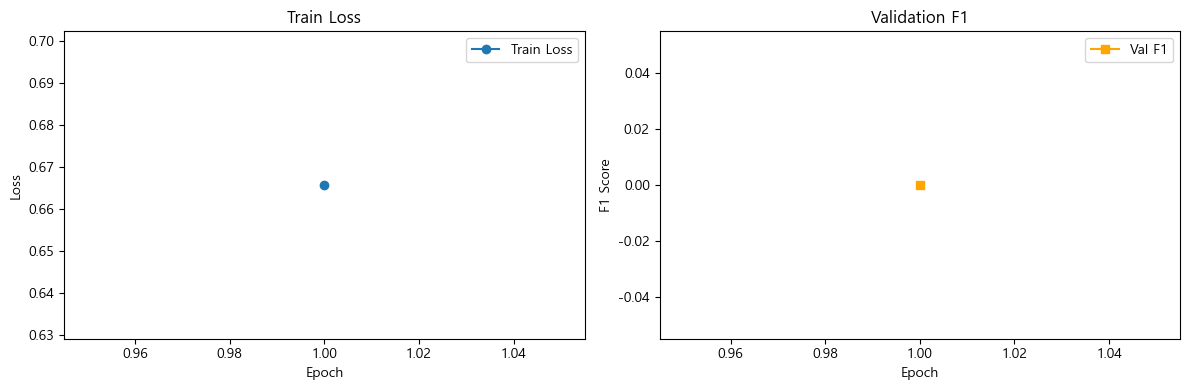

In [ ]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["font.family"] = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False

if bert.history["train_loss"]:
    epochs_range = range(1, len(bert.history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs_range, bert.history["train_loss"], marker="o", label="Train Loss")
    axes[0].set_title("Train Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    if bert.history["val_f1"]:
        axes[1].plot(epochs_range, bert.history["val_f1"], marker="s", color="orange", label="Val F1")
        axes[1].set_title("Validation F1")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("F1 Score")
        axes[1].legend()

        # 오버피팅 진단
        peak_epoch = bert.history["val_f1"].index(max(bert.history["val_f1"])) + 1
        last_loss  = bert.history["train_loss"][-1]
        peak_f1    = max(bert.history["val_f1"])
        last_f1    = bert.history["val_f1"][-1]
        print(f"최적 Val F1: {peak_f1:.4f} (Epoch {peak_epoch})")
        if last_f1 < peak_f1 - 0.02:
            print("⚠️  Val F1 하락 감지 — 최적 체크포인트 자동 복원 적용됨")
        else:
            print("✅  학습 안정적")

    plt.tight_layout()
    plt.show()
else:
    print("학습 히스토리 없음 — fit() 후 실행하세요")

## 모델 저장

In [ ]:
import os
os.makedirs('../artifacts', exist_ok=True)
bert.save('../artifacts/bert_model')
print('저장 완료!')

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.13it/s]

[BERT] 모델 저장: ../artifacts/bert_model
저장 완료!


## 직접 테스트

In [ ]:
test_cases = [
    ('무료 대출 1억 지금 바로 신청', '신용등급 상관없이 당일 대출 가능합니다. 지금 클릭하세요!'),
    ('내일 회의 자료 공유드립니다', '안녕하세요. 내일 오전 10시 회의 자료 첨부드립니다. 검토 부탁드립니다.'),
    ('당신이 선택되었습니다!', '축하합니다! 1등 당첨! 지금 바로 수령하세요. 010-0000-0000'),
]

for subject, body in test_cases:
    text = pre.preprocess(subject, body)
    result = bert.predict_single(text)
    bar = '█' * int(result.spam_probability * 20)
    print(f'[{result.label.upper():4s}] spam={result.spam_probability:.2%} |{bar:<20}| 제목: {subject}')

[HAM ] spam=46.07% |█████████           | 제목: 무료 대출 1억 지금 바로 신청
[HAM ] spam=41.61% |████████            | 제목: 내일 회의 자료 공유드립니다
[HAM ] spam=43.23% |████████            | 제목: 당신이 선택되었습니다!


---

## 하이퍼파라미터 튜닝 (Optuna)

`learning_rate`, `warmup_ratio`, `weight_decay`, `batch_size` 를 자동 탐색합니다.

- **n_trials=10** : 10번 탐색 (늘릴수록 정확하지만 느림)
- **TUNE_EPOCHS=2** : 탐색 중에는 2에폭만 학습 (속도 절충)
- CPU 환경에서는 **n_trials=3** 으로 자동 축소됩니다.

In [ ]:
import optuna
from sklearn.metrics import f1_score

# CPU면 빠른 탐색, GPU면 본격 탐색
N_TRIALS   = 3  if QUICK_TEST else 10
TUNE_EPOCHS = 2 if QUICK_TEST else 3

# 튜닝용 데이터 (CPU면 소규모 유지)
X_tune_tr = X_tr
y_tune_tr = y_tr
X_tune_v  = X_v
y_tune_v  = y_v

def objective(trial: optuna.Trial) -> float:
    lr      = trial.suggest_float('learning_rate', 1e-5, 5e-5, log=True)
    warmup  = trial.suggest_float('warmup_ratio',  0.05, 0.2)
    wd      = trial.suggest_float('weight_decay',  0.0,  0.1)
    bs      = trial.suggest_categorical('batch_size', [8, 16] if QUICK_TEST else [16, 32])

    m = BERTSpamClassifier(
        base_model=MODEL_NAME,
        max_length=128,
        batch_size=bs,
        epochs=TUNE_EPOCHS,
        learning_rate=lr,
        warmup_ratio=warmup,
        weight_decay=wd,
        spam_threshold=0.7,
    )
    m.fit(X_tune_tr, y_tune_tr, X_tune_v, y_tune_v)

    preds  = [1 if r.label == 'spam' else 0 for r in m.predict(X_tune_v)]
    return f1_score(y_tune_v, preds, pos_label=1)

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print('\n최적 파라미터:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')
print(f'\nVal F1: {study.best_value:.4f}')

  0%|          | 0/3 [00:00<?, ?it/s]

[BERT] 디바이스: cpu


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 46433.15it/s]
ElectraForSequenceClassification LOAD REPORT from: snunlp/KR-ELECTRA-discriminator
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
electra.embeddings.position_ids                   | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.weight                           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[BERT] Epoch 1/2 | train_loss=0.6656 | val_f1=0.0000
[BERT] Epoch 2/2 | train_loss=0.5933 | val_f1=0.4516
[BERT] 최적 모델 복원 (val_f1=0.4516)


Best trial: 0. Best value: 0:  33%|███▎      | 1/3 [01:23<02:46, 83.24s/it]

...

[BERT] 디바이스: cpu


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 46592.87it/s]
ElectraForSequenceClassification LOAD REPORT from: snunlp/KR-ELECTRA-discriminator
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
electra.embeddings.position_ids                   | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.weight                           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[BERT] Epoch 1/2 | train_loss=0.6708 | val_f1=0.0000
[BERT] Epoch 2/2 | train_loss=0.5992 | val_f1=0.2857
[BERT] 최적 모델 복원 (val_f1=0.2857)


Best trial: 1. Best value: 0.809524: 100%|██████████| 3/3 [04:10<00:00, 83.48s/it]


최적 파라미터:
  learning_rate: 4.5448882659631545e-05
  warmup_ratio: 0.0991603751193074
  weight_decay: 0.02606179171593427
  batch_size: 8

Val F1: 0.8095


In [ ]:
# 최적 파라미터로 재학습 & 최종 평가
bp = study.best_params

tuned_bert = BERTSpamClassifier(
    base_model=MODEL_NAME,
    max_length=128,
    batch_size=bp['batch_size'],
    epochs=epochs,
    learning_rate=bp['learning_rate'],
    warmup_ratio=bp['warmup_ratio'],
    weight_decay=bp['weight_decay'],
    spam_threshold=0.7,
)

tuned_bert.fit(X_tr, y_tr, X_v, y_v)

X_test_eval = data.X_test[:100] if QUICK_TEST else data.X_test
y_test_eval = data.y_test[:100] if QUICK_TEST else data.y_test

results_tuned = tuned_bert.predict(X_test_eval)
y_pred_tuned  = [1 if r.label == 'spam' else 0 for r in results_tuned]

print('=== 튜닝 후 Test 결과 ===')
print(classification_report(y_test_eval, y_pred_tuned, target_names=['ham', 'spam']))

[BERT] 디바이스: cpu


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 51635.91it/s]
ElectraForSequenceClassification LOAD REPORT from: snunlp/KR-ELECTRA-discriminator
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
electra.embeddings.position_ids                   | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.weight                           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[BERT] Epoch 1/1 | train_loss=0.6035 | val_f1=0.5714
[BERT] 최적 모델 복원 (val_f1=0.5714)
=== 튜닝 후 Test 결과 ===
              precision    recall  f1-score   support

         ham       0.47      1.00      0.64        47
        spam       0.00      0.00      0.00        53

    accuracy                           0.47       100
   macro avg       0.23      0.50      0.32       100
weighted avg       0.22      0.47      0.30       100



c:\Users\ion01\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ion01\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ion01\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

---

## 임계값 최적화 (ROC 커브)

ROC 커브로 BERT 모델의 최적 스팸 판정 임계값을 찾습니다.

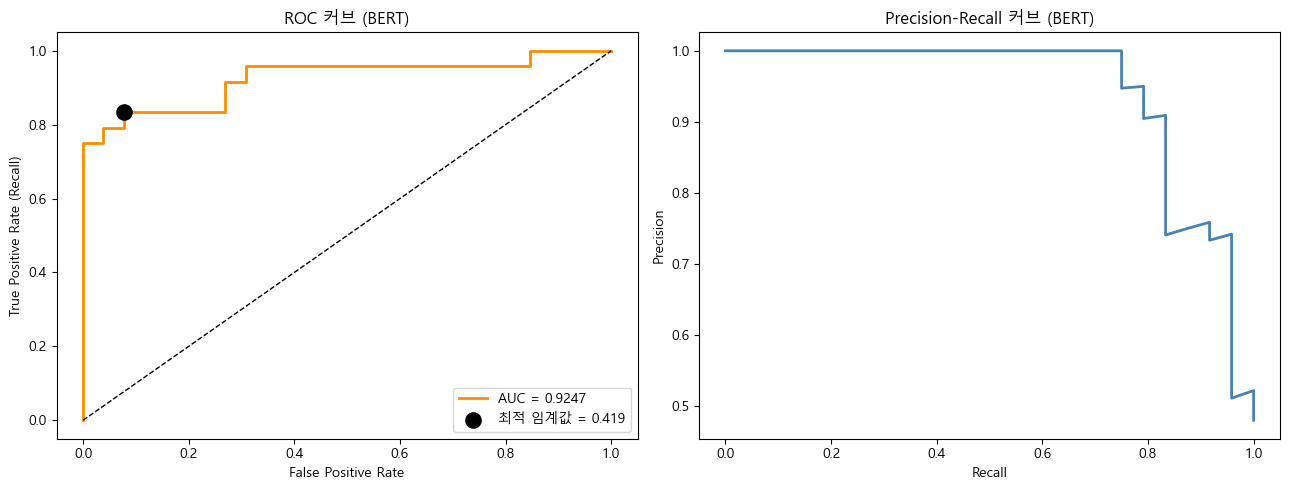


현재 임계값  : 0.700
최적 임계값  : 0.419  (Youden J 기준)
ROC AUC     : 0.9247


In [ ]:
import numpy as np
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# val 세트 스팸 확률 추출
spam_probs_val  = [proba[1] for proba in bert.predict_proba(X_v)]
spam_probs_test = [proba[1] for proba in bert.predict_proba(X_test_eval)]

# ── ROC 커브 ──────────────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(y_v, spam_probs_val, pos_label=1)
roc_auc = auc(fpr, tpr)

# Youden's J 기준 최적 임계값
j_scores  = tpr - fpr
best_idx  = np.argmax(j_scores)
best_threshold = thresholds[best_idx]

# ── Precision-Recall 커브 ─────────────────────────────────────
precision, recall, _ = precision_recall_curve(y_v, spam_probs_val)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
axes[0].scatter(fpr[best_idx], tpr[best_idx], s=120, zorder=5,
                color='black', label=f'최적 임계값 = {best_threshold:.3f}')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].set_title('ROC 커브 (BERT)')
axes[0].legend()

axes[1].plot(recall, precision, color='steelblue', lw=2)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall 커브 (BERT)')

plt.tight_layout()
plt.show()

print(f'\n현재 임계값  : 0.700')
print(f'최적 임계값  : {best_threshold:.3f}  (Youden J 기준)')
print(f'ROC AUC     : {roc_auc:.4f}')

In [ ]:
# 최적 임계값으로 test 세트 재평가
bert.SPAM_THRESHOLD = best_threshold

results_opt = bert.predict(X_test_eval)
y_pred_opt  = [1 if r.label == 'spam' else 0 for r in results_opt]

print(f'=== 임계값 {best_threshold:.3f} 적용 후 Test 결과 ===')
print(classification_report(y_test_eval, y_pred_opt, target_names=['ham', 'spam']))

=== 임계값 0.419 적용 후 Test 결과 ===
              precision    recall  f1-score   support

         ham       0.75      0.89      0.82        47
        spam       0.89      0.74      0.80        53

    accuracy                           0.81       100
   macro avg       0.82      0.81      0.81       100
weighted avg       0.82      0.81      0.81       100

